# Project Overview: Generative Augmentation for Minority Disease Detection

### Choice of Dataset: [Skin Cancer: Malignant vs. Benign](https://www.kaggle.com/datasets/fanconic/skin-cancer-malignant-vs-benign/data)

This dataset is a processed, lightweight subset of the massive ISIC (International Skin Imaging Collaboration) Archive. It contains high-quality images of skin lesions categorized into two distinct classes:
* **Benign:** Non-cancerous skin moles.
* **Malignant:** Cancerous skin lesions (Melanoma).

#### Dataset Structure
| Category | Training Set (2,637 images) | Testing Set (660 images) |
| :--- | :--- | :--- |
| **Benign** | 1,440 | 360 |
| **Malignant** | 1,197 | 300 |

#### Directory Hierarchy
```text
data/
├── train/
│   ├── benign/
│   └── malignant/
└── test/
    ├── benign/
    └── malignant/
```

---

### Motivation
In real-world medical imaging, acquiring labeled data for specific, severe diseases is costly, time-consuming, and constrained by privacy considerations. As a result, clinical datasets are often highly imbalanced, with healthy/benign cases vastly outnumbering positive disease cases, which biases supervised learning models toward the majority class.

### Rationale for Artificial Downsampling
While the full 30,000+ image ISIC archive exhibits this severe natural imbalance, the lightweight Kaggle subset we are using has been artificially balanced.

To properly test our hypothesis regarding minority-class starvation, **we will artificially reconstruct the real-world clinical problem.**
* We will keep all 1,440 Benign training images and downsample the Malignant training images from 1,197 down to just **120 images**, to create a severe **12:1 class imbalance**, similar to the full dataset.

### Hypothesis
We hypothesize that modern deep generative models can successfully mitigate this extreme class imbalance by synthetically generating highly realistic, biologically plausible minority-class data. Specifically, we anticipate that **Diffusion-based augmentation will significantly outperform both Classical augmentation and GAN-based augmentation**, resulting in the highest Malignant Recall score for our classifier.

---

### Notebook Structure and Experimental Setup
To test this hypothesis, this notebook is structured into the following phases. We will use a regularized **ResNet18** as our core Convolutional Neural Network (CNN) classifier for all tests.

1.  **Data Preprocessing:** Loading the dataset, establishing a locked Validation/Test split, and inducing the 12:1 artificial imbalance on the Training set.

2.  **Experiment 1 (The Baseline):** Training the CNN strictly on the imbalanced data to establish our baseline performance floor.

3.  **Experiment 2 (Classical Augmentation):** Attempting to balance the dataset using standard transformations and evaluating the CNN.

4.  **Experiment 3 (GAN Augmentation):** Training a Deep Convolutional GAN (DCGAN) on the 120 malignant images to synthesize new data, balancing the training set, and evaluating the CNN.

5.  **Experiment 4 (Diffusion Augmentation):** Using a diffusion model to synthesize high-fidelity malignant images, balancing the training set, and evaluating the CNN

6.  **Final Benchmark:** A head-to-head comparison of key performance metrics across all four methodologies.

In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, recall_score
import copy

In [2]:
dataset_path = '/home/hassay/lab1/data'

In [ ]:
def get_df(split):
    """Construct a dataframe of the path of each image and its label."""
    data = []
    for label in ['benign', 'malignant']:
        path = os.path.join(dataset_path, split, label)
        if os.path.exists(path):
            for file in os.listdir(path):
                data.append({'path': os.path.join(path, file), 'label': label})
    return pd.DataFrame(data)

In [10]:
df_train_full = get_df('train')
df_test = get_df('test')

In [ ]:
df_train_full.head()

,path,label
0,/home/hassay/lab1/data/train/benign/1447.jpg,benign
1,/home/hassay/lab1/data/train/benign/1670.jpg,benign
2,/home/hassay/lab1/data/train/benign/627.jpg,benign
3,/home/hassay/lab1/data/train/benign/258.jpg,benign
4,/home/hassay/lab1/data/train/benign/1690.jpg,benign


In [7]:
df_test.head()

,path,label
0,/home/hassay/lab1/data/test/benign/1377.jpg,benign
1,/home/hassay/lab1/data/test/benign/1602.jpg,benign
2,/home/hassay/lab1/data/test/benign/631.jpg,benign
3,/home/hassay/lab1/data/test/benign/385.jpg,benign
4,/home/hassay/lab1/data/test/benign/1559.jpg,benign


In [49]:
# HYPERPARAMETERS
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
TRAINING_EPOCHS = 15

In [47]:
DEVICE

device(type='cuda', index=2)

In [56]:
# Original df_test has 360 benign, 300 malignant
test_benign_full = df_test[df_test['label'] == 'benign']
test_malignant_full = df_test[df_test['label'] == 'malignant']

In [57]:
# Sample half for validation
val_benign = test_benign_full.sample(n=180, random_state=SEED)
val_malignant = test_malignant_full.sample(n=150, random_state=SEED)
df_val = pd.concat([val_benign, val_malignant]).sample(frac=1, random_state=SEED).reset_index(drop=True)

In [58]:
# Use the exact remainders for the Final Test (180 Benign, 150 Malignant)
final_test_benign = test_benign_full.drop(val_benign.index)
final_test_malignant = test_malignant_full.drop(val_malignant.index)
df_test_final = pd.concat([final_test_benign, final_test_malignant]).sample(frac=1, random_state=SEED).reset_index(drop=True)

In [59]:
# Create imbalance from training set
train_benign = df_train_full[df_train_full['label'] == 'benign']
train_malignant_full = df_train_full[df_train_full['label'] == 'malignant']
# Downsample malignant to 120 (Creates a 12:1 imbalance)
train_malignant_imbalanced = train_malignant_full.sample(n=120, random_state=SEED)
df_train_imbalanced = pd.concat([train_benign, train_malignant_imbalanced]).sample(frac=1, random_state=SEED).reset_index(drop=True)

In [60]:
total_images = len(df_train_imbalanced) + len(df_val) + len(df_test_final)

def print_stats(name, df):
    count = len(df)
    percent = (count / total_images) * 100
    print(f"\n{name}")
    print(f"Total: {count} images ({percent:.1f}% of total)")
    print(f"Class Distribution:\n{df['label'].value_counts().to_string()}")

print_stats("1. Training Set", df_train_imbalanced)
print_stats("2. Validation Set", df_val)
print_stats("3. Testing Set", df_test_final)


1. Training Set
Total: 1560 images (70.3% of total)
Class Distribution:
label
benign       1440
malignant     120

2. Validation Set
Total: 330 images (14.9% of total)
Class Distribution:
label
benign       180
malignant    150

3. Testing Set
Total: 330 images (14.9% of total)
Class Distribution:
label
benign       180
malignant    150


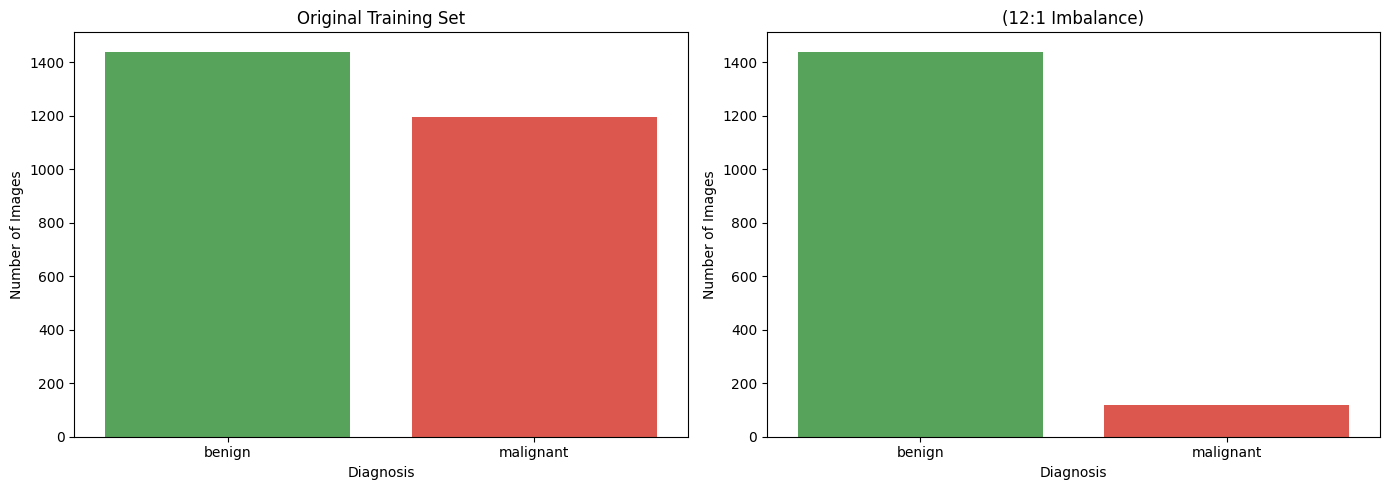

In [61]:
# Plot Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_colors = {'benign': '#4CAF50', 'malignant': '#F44336'} # Green for Benign, Red for Malignant

# Plot 1: The Original Dataset
sns.countplot(data=df_train_full, x='label', hue='label', ax=axes[0], palette=palette_colors, order=['benign', 'malignant'], legend=False)
axes[0].set_title("Original Training Set")
axes[0].set_ylabel("Number of Images")
axes[0].set_xlabel("Diagnosis")

# Plot 2: The Artificially Imbalanced Dataset
sns.countplot(data=df_train_imbalanced, x='label', hue='label', ax=axes[1], palette=palette_colors, order=['benign', 'malignant'], legend=False)
axes[1].set_title("(12:1 Imbalance)")
axes[1].set_ylabel("Number of Images")
axes[1].set_xlabel("Diagnosis")

plt.tight_layout()
plt.show()

In [24]:
def verify_all_image_sizes(df_list):
    unique_sizes = set()
    
    for df in df_list:
        for path in df['path']:
            with Image.open(path) as img:
                unique_sizes.add(img.size)
                
    print("\nUnique image dimensions found (Width x Height):")
    for size in unique_sizes:
        print(f"- {size[0]} x {size[1]}")

verify_all_image_sizes([df_train_full, df_test])


Unique image dimensions found (Width x Height):
- 224 x 224


In [34]:
class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.label_map = {'benign': 0.0, 'malignant': 1.0}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[self.dataframe.iloc[idx]['label']]
        
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor([label], dtype=torch.float32)

In [36]:
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Failsafe
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the pixel values to have a mean of 0 and std of 1 (helps CNNs learn faster)
])

In [39]:
train_dataset = ISICDataset(df_train_imbalanced, transform=baseline_transforms)
val_dataset   = ISICDataset(df_val, transform=baseline_transforms)
test_dataset  = ISICDataset(df_test_final, transform=baseline_transforms)

In [41]:
train_baseline_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [48]:
def get_optimal_baseline():
    """Returns a ResNet18 with a regularized head"""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Freeze the foundational layers to focus learning on our specific data
    for param in model.parameters():
        param.requires_grad = False
        
    # Replace the classification head and inject 50% Dropout
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 1) # binary classification
    )
    return model.to(DEVICE)

In [52]:
def train_model(model, train_loader):
    criterion = nn.BCEWithLogitsLoss() 
    optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_recall': []}

    print(f"Starting Training on {DEVICE} for {TRAINING_EPOCHS} epochs...")
    # EARLY STOPPING & BEST MODEL TRACKING SETUP
    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    patience=5

    for epoch in range(TRAINING_EPOCHS):
        # Training Phase
        model.train()
        train_losses, train_preds, train_targets = [], [], []
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            # Clear old gradients
            optimizer.zero_grad()
            # Forward pass
            outputs = model(images)
            # Calculate loss
            loss = criterion(outputs, labels)
            # Backward pass
            loss.backward()
            # Update weights
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())
            
        history['train_loss'].append(np.mean(train_losses))
        history['train_acc'].append(accuracy_score(train_targets, train_preds))
        
        # Validation Phase
        model.eval()
        val_losses, val_preds, val_targets = [], [], []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_losses.append(loss.item())
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
                
        current_val_loss = np.mean(val_losses)
        history['val_loss'].append(current_val_loss)
        history['val_acc'].append(accuracy_score(val_targets, val_preds))
        history['val_recall'].append(recall_score(val_targets, val_preds, zero_division=0))
        
        print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Recall: {history['val_recall'][-1]:.4f}")     

        if current_val_loss < best_loss:
            best_loss = current_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs. Validation loss hasn't improved for {patience} epochs.")
                break
    print(f"Training complete. Loading best model weights (Val Loss: {best_loss:.4f})")
    model.load_state_dict(best_model_wts)
    return model, history

In [63]:
def plot_training_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Loss curves
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='orange')
    ax1.set_title(f'{model_name} Loss (Early Stopping Tracked)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot 2: Validation Accuracy vs Recall
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='green')
    ax2.plot(history['val_recall'], label='Malignant Recall', color='red', linestyle='--')
    ax2.set_title(f'{model_name} Performance Metrics')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [54]:
# Train Baseline
baseline_model = get_optimal_baseline()
trained_baseline, baseline_history = train_model(model=baseline_model, train_loader=train_baseline_loader)

Starting Training on cuda:2 for 15 epochs...
Epoch [1/15] | Train Loss: 0.3833 | Val Loss: 1.1944 | Val Recall: 0.0000
Epoch [2/15] | Train Loss: 0.2921 | Val Loss: 1.3737 | Val Recall: 0.0000
Epoch [3/15] | Train Loss: 0.2779 | Val Loss: 1.3439 | Val Recall: 0.0000
Epoch [4/15] | Train Loss: 0.2763 | Val Loss: 1.3053 | Val Recall: 0.0000
Epoch [5/15] | Train Loss: 0.2718 | Val Loss: 1.2562 | Val Recall: 0.0000
Epoch [6/15] | Train Loss: 0.2682 | Val Loss: 1.2528 | Val Recall: 0.0000

Early stopping triggered after 6 epochs. Validation loss hasn't improved for 5 epochs.
Training complete. Loading best model weights (Val Loss: 1.1944)


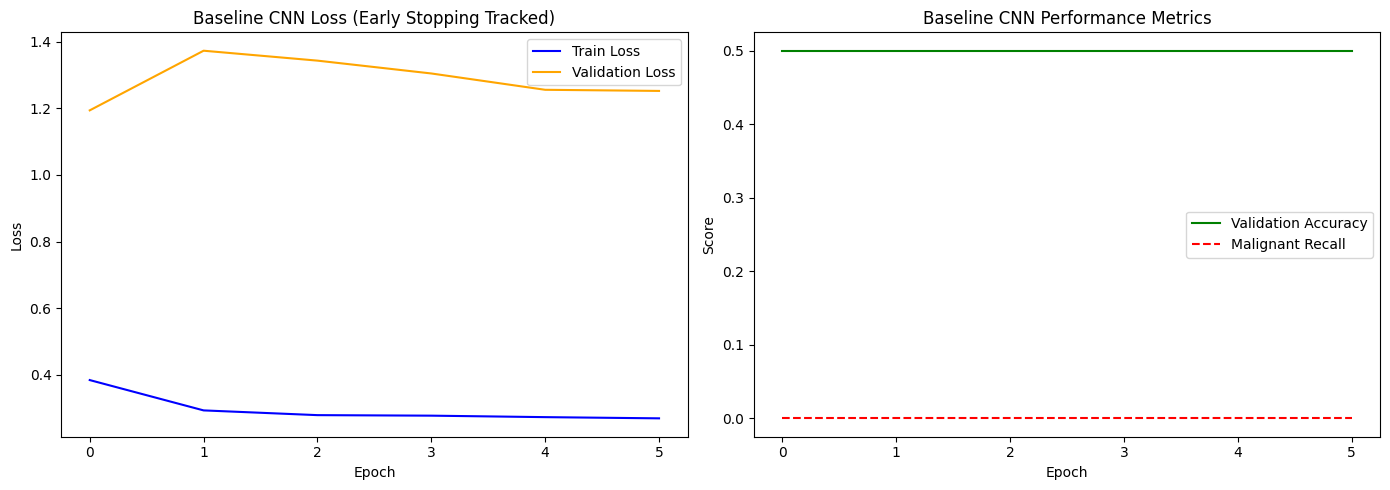

In [64]:
plot_training_history(baseline_history, model_name="Baseline CNN")